# RLC resonance -- the curve, the Q, and finding the peak by optimization
### sweep the frequency for the resonance, then let torch climb to it

Drive a series RLC at frequency $\omega$. The bandpass response is
$$H(\omega)=\frac{R}{R+j(\omega L-1/\omega C)},$$
and the inductor's $+\omega L$ cancels the capacitor's $-1/\omega C$ at
$$\omega_0=\frac{1}{\sqrt{LC}}\quad(\text{resonance}),$$
where $|H|=1$, the current peaks, and the phase crosses zero. The peak's sharpness is
$Q=\tfrac1R\sqrt{L/C}$ and its $-3$ dB width is $\omega_0/Q$. We sweep the frequency for
the curve (matplotlib) and then find the peak by **gradient optimization** (torch) --
two ways to the same $\omega_0$. It is the same $\omega_0=\sqrt{k/m}$ as the mechanical
oscillator (`dgs.lagrangian`) -- resonance behind tuners, filters, and receivers.
Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import torch
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import resonance as r
L, C = 1e-3, 1e-6; w0 = r.resonant_frequency(L, C)
print(f"omega0 = 1/sqrt(LC) = {w0:.0f} rad/s  (f0 = {w0/2/np.pi:.0f} Hz)")

omega0 = 1/sqrt(LC) = 31623 rad/s  (f0 = 5033 Hz)


## 1. The resonance curve -- and the role of Q

Sweep $\omega$ and plot $|H|$. The peak sits at $\omega_0$ regardless of R, but R sets
the **sharpness**: small R = high Q = a tall narrow peak (a selective radio tuner);
large R = low Q = broad and flat.

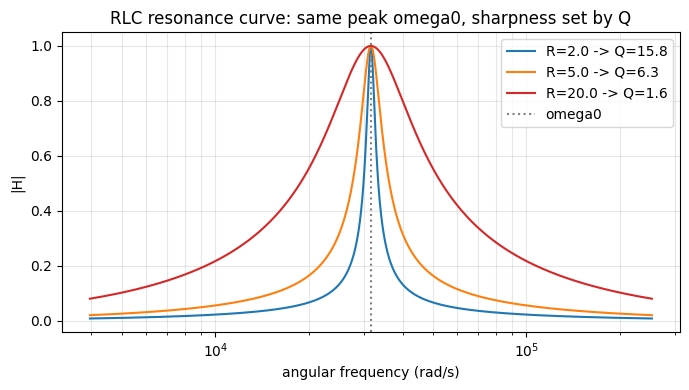

In [2]:
w = np.logspace(np.log10(w0/8), np.log10(w0*8), 4000)
plt.figure(figsize=(7,4))
for R, c in [(2.0,"C0"),(5.0,"C1"),(20.0,"C3")]:
    plt.plot(w, np.abs(r.rlc_response(w, R, L, C)), color=c,
             label=f"R={R} -> Q={r.quality_factor(R,L,C):.1f}")
plt.axvline(w0, ls=":", color="gray", label="omega0")
plt.xscale("log"); plt.xlabel("angular frequency (rad/s)"); plt.ylabel("|H|")
plt.title("RLC resonance curve: same peak omega0, sharpness set by Q"); plt.legend()
plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## 2. At resonance the reactance cancels (and the phase flips)

The reactance $X(\omega)=\omega L-1/\omega C$ crosses **zero** at $\omega_0$: below it the
capacitor dominates (negative, current leads), above it the inductor dominates
(positive, current lags). At the crossing the impedance is purely R and the phase of
$H$ is zero -- the signature you look for on the bench.

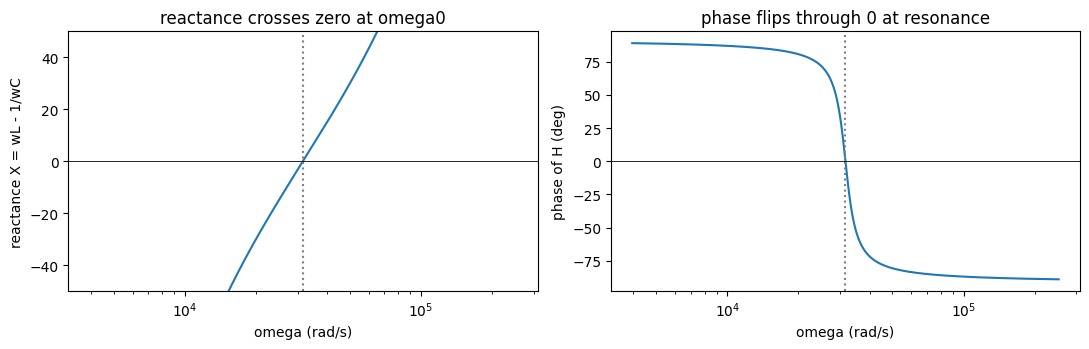

In [3]:
X = w*L - 1.0/(w*C)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(w, X); ax[0].axhline(0, color="k", lw=0.6); ax[0].axvline(w0, ls=":", color="gray")
ax[0].set(xscale="log", xlabel="omega (rad/s)", ylabel="reactance X = wL - 1/wC",
          title="reactance crosses zero at omega0"); ax[0].set_ylim(-50, 50)
ax[1].plot(w, np.degrees(np.angle(r.rlc_response(w, 5.0, L, C))))
ax[1].axhline(0, color="k", lw=0.6); ax[1].axvline(w0, ls=":", color="gray")
ax[1].set(xscale="log", xlabel="omega (rad/s)", ylabel="phase of H (deg)",
          title="phase flips through 0 at resonance")
plt.tight_layout(); plt.show()

## 3. Q and bandwidth, read off the curve ("the experiment")

Sweep, find the peak, and measure $Q$ as the peak frequency over the $-3$ dB width --
exactly how you characterize a resonance on a bench. The measured $Q$ matches
$\tfrac1R\sqrt{L/C}$.

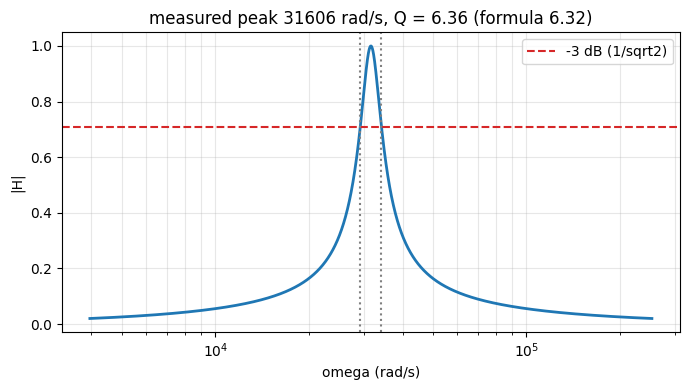

In [4]:
R = 5.0
omega, H = r.frequency_sweep(R, L, C)
w_pk, Q_meas = r.find_resonance(omega, H)
lo, hi = w0 - r.bandwidth(R,L)/2, w0 + r.bandwidth(R,L)/2
plt.figure(figsize=(7,4))
plt.plot(omega, np.abs(H), lw=2)
plt.axhline(1/np.sqrt(2), ls="--", color="C3", label="-3 dB (1/sqrt2)")
plt.axvline(lo, ls=":", color="gray"); plt.axvline(hi, ls=":", color="gray")
plt.xscale("log"); plt.xlabel("omega (rad/s)"); plt.ylabel("|H|"); plt.legend()
plt.title(f"measured peak {w_pk:.0f} rad/s, Q = {Q_meas:.2f} (formula {r.quality_factor(R,L,C):.2f})")
plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## 4. Find the peak by OPTIMIZATION (torch)

Instead of the formula or a fine sweep, let **torch** climb to the resonance:
gradient-descend the impedance magnitude $|Z(\omega)|$ (which is minimized exactly at
$\omega_0$, where the current is maximal). Start off-peak and watch it converge to
$\omega_0$ -- the autograd version of turning the dial until the meter peaks.

torch optimization found omega0 = 31622.8 rad/s (formula 31622.8)


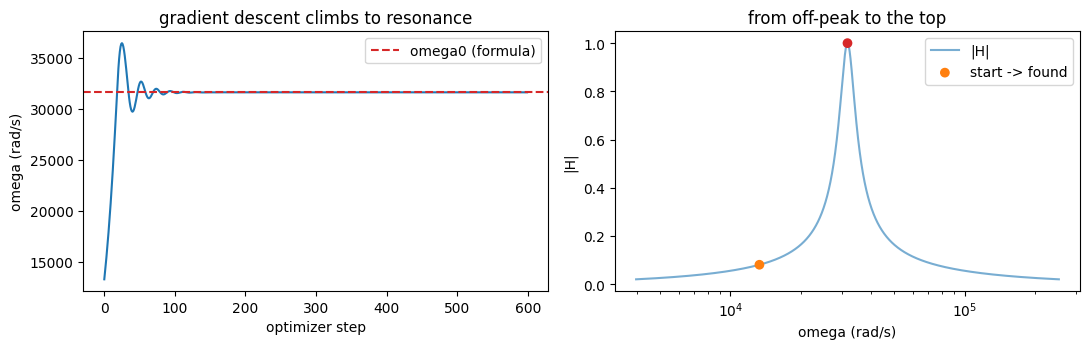

In [5]:
w_found, traj = r.find_resonance_torch(R, L, C, steps=600)
print(f"torch optimization found omega0 = {w_found:.1f} rad/s (formula {w0:.1f})")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(traj); ax[0].axhline(w0, ls="--", color="C3", label="omega0 (formula)")
ax[0].set(xlabel="optimizer step", ylabel="omega (rad/s)",
          title="gradient descent climbs to resonance"); ax[0].legend()
ax[1].plot(w, np.abs(r.rlc_response(w, R, L, C)), alpha=0.6, label="|H|")
ax[1].scatter([traj[0], traj[-1]], [abs(r.rlc_response(traj[0],R,L,C)), abs(r.rlc_response(traj[-1],R,L,C))],
              c=["C1","C3"], zorder=5, label="start -> found")
ax[1].set(xscale="log", xlabel="omega (rad/s)", ylabel="|H|", title="from off-peak to the top"); ax[1].legend()
plt.tight_layout(); plt.show()

## Takeaway

1. A series RLC peaks at $\omega_0=1/\sqrt{LC}$, where the reactances cancel: $|H|=1$,
   phase $0$, current maximal.
2. **Q** $=\tfrac1R\sqrt{L/C}$ sets the peak's sharpness; the $-3$ dB bandwidth is
   $\omega_0/Q$. You read both off a frequency sweep.
3. The peak can be **optimized to** (torch gradient descent on $|Z|$), not just
   computed -- the same answer two ways.

This $\omega_0=1/\sqrt{LC}$ is the electrical twin of the mechanical $\sqrt{k/m}$ and the
normal-mode frequencies from `dgs.lagrangian` / `dgs.eigen_modes` -- one resonance
under tuners, filters, and every receiver front end. Civilian education.